<a href="https://colab.research.google.com/github/kaplunov-dmitrii/diffury/blob/main/2253_%D0%9A%D0%B0%D0%BF%D0%BB%D1%83%D0%BD%D0%BE%D0%B2_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_%D0%BF%D1%80%D0%BE_%D0%BA%D0%B0%D1%82%D0%B5%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [61]:
k = 0.5
p0 = 2
m = 1
tau = 2

In [62]:
t = sp.symbols("t")
v = sp.Function("V")(t)
ode = sp.Eq(v.diff(t), (p0*sp.exp(-t/tau) / m * (1/v)) - k*v/m)
ode

Eq(Derivative(V(t), t), -0.5*V(t) + 2*exp(-t/2)/V(t))

In [63]:
v0 = 1.5
t0 = 0
t_end = 10
t_points = np.linspace(t0, t_end, 500)

In [64]:
solution = sp.dsolve(ode, v, ics={v.func(0): v0})
solution

Eq(V(t), 2.82842712474619*sqrt((1.0*exp(t)**0.5 - 0.71875)*exp(-1.0*t)))

In [65]:
#Ручное решение
v_analytical_values = np.sqrt(8 * np.exp(-t_points / 2) - 5.75 * np.exp(-t_points))

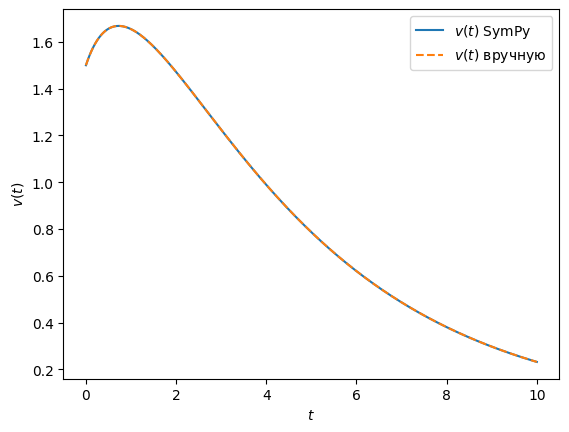

In [66]:
v_func = sp.lambdify(t, solution.rhs, 'numpy')
v_values = v_func(t_points)

plt.plot(t_points, v_values, label=r'$v(t)$ SymPy')
plt.plot(t_points, v_analytical_values, label=r'$v(t)$ вручную', linestyle='--')

plt.xlabel(r'$t$')
plt.ylabel(r'$v(t)$')
plt.legend()
plt.show()

In [67]:
v_tau_2 = np.sqrt(8 * np.exp(-t_points / 2) - 5.75 * np.exp(-t_points))
v_tau_5 = np.sqrt(5 * np.exp(-t_points / 5) - 2.75 * np.exp(-t_points))
v_tau_10 = np.sqrt(4.44 * np.exp(-t_points / 10) - 2.19 * np.exp(-t_points))

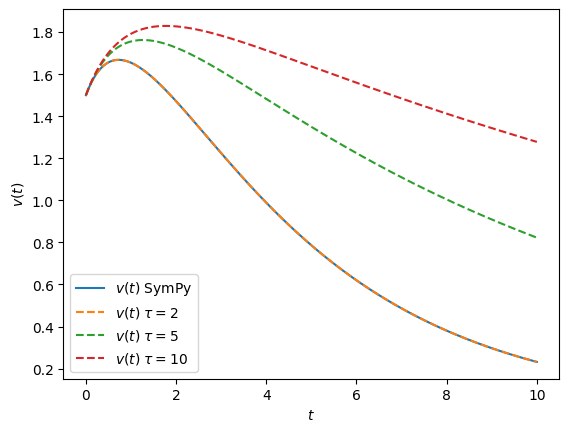

In [68]:
plt.plot(t_points, v_values, label=r'$v(t)$ SymPy')
plt.plot(t_points, v_tau_2, label=r'$v(t)$ $\tau=2$', linestyle='--')
plt.plot(t_points, v_tau_5, label=r'$v(t)$ $\tau=5$', linestyle='--')
plt.plot(t_points, v_tau_10, label=r'$v(t)$ $\tau=10$', linestyle='--')

plt.xlabel(r'$t$')
plt.ylabel(r'$v(t)$')
plt.legend()
plt.show()